In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from pathlib import Path
from lifelines import KaplanMeierFitter
from statsmodels.nonparametric.smoothers_lowess import lowess
import statsmodels.api as sm
import numpy as np

# Note: This script retains the original thesis development paths and is not intended
# to be executed in the public repository without access to the private data environment.

MAIN_DIR = Path("/Users/chanyoungwoo/Thesis/ATE_CATE")
CATE_H1_FP = MAIN_DIR / "Model_New_horizon_1/csf_cate_train.csv"
CATE_H2_FP = MAIN_DIR / "Model_New_horizon_2/csf_cate_train.csv"
CATE_H3_FP = MAIN_DIR / "Model_New_horizon_3/csf_cate_train.csv"
CATE_H1_TEST_FP = MAIN_DIR / "Model_New_horizon_1/csf_cate_test.csv"
CATE_H2_TEST_FP = MAIN_DIR / "Model_New_horizon_2/csf_cate_test.csv"
CATE_H3_TEST_FP = MAIN_DIR / "Model_New_horizon_3/csf_cate_test.csv"
VI_H1_FP   = MAIN_DIR / "Model_New_horizon_1/csf_variable_importance.csv"
VI_H2_FP   = MAIN_DIR / "Model_New_horizon_2/csf_variable_importance.csv"
VI_H3_FP   = MAIN_DIR / "Model_New_horizon_3/csf_variable_importance.csv"
PARQUET_FP   = MAIN_DIR / "CSF_data_NEW2/cand_kipa_csf_data_train.parquet"
PARQUET_TEST_FP   = MAIN_DIR / "CSF_data_NEW2/cand_kipa_test_ver10.parquet"


h1 = pd.read_csv(CATE_H1_FP).rename(columns={"tau":"tau1"})
h2 = pd.read_csv(CATE_H2_FP).rename(columns={"tau":"tau2"})
h3 = pd.read_csv(CATE_H3_FP).rename(columns={"tau":"tau3"})
df = h1.merge(h2, on="PX_ID").merge(h3, on="PX_ID")

h1_test = pd.read_csv(CATE_H1_TEST_FP).rename(columns={"tau":"tau1"})
h2_test = pd.read_csv(CATE_H2_TEST_FP).rename(columns={"tau":"tau2"})
h3_test = pd.read_csv(CATE_H3_TEST_FP).rename(columns={"tau":"tau3"})
df_test = h1_test.merge(h2_test, on="PX_ID").merge(h3_test, on="PX_ID")

vi_h1 = pd.read_csv(VI_H1_FP)
vi_h2 = pd.read_csv(VI_H2_FP)
vi_h3 = pd.read_csv(VI_H3_FP)

In [15]:
for a,b in [("tau1","tau2"),("tau1","tau3"),("tau2","tau3")]:
    corr, p = pearsonr(df_test[a], df_test[b])
    print(f"{a} vs {b}: ρ={corr:.3f} (p={p:.1e})")

tau1 vs tau2: ρ=0.905 (p=0.0e+00)
tau1 vs tau3: ρ=0.815 (p=0.0e+00)
tau2 vs tau3: ρ=0.967 (p=0.0e+00)


In [ ]:
# force same axis
all_vals = df_test[["tau1", "tau2", "tau3"]].to_numpy().ravel()
vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)
pad = 0.05 * (vmax - vmin if vmax > vmin else 1.0)
xmin, xmax = vmin - pad, vmax + pad
ymin, ymax = xmin, xmax

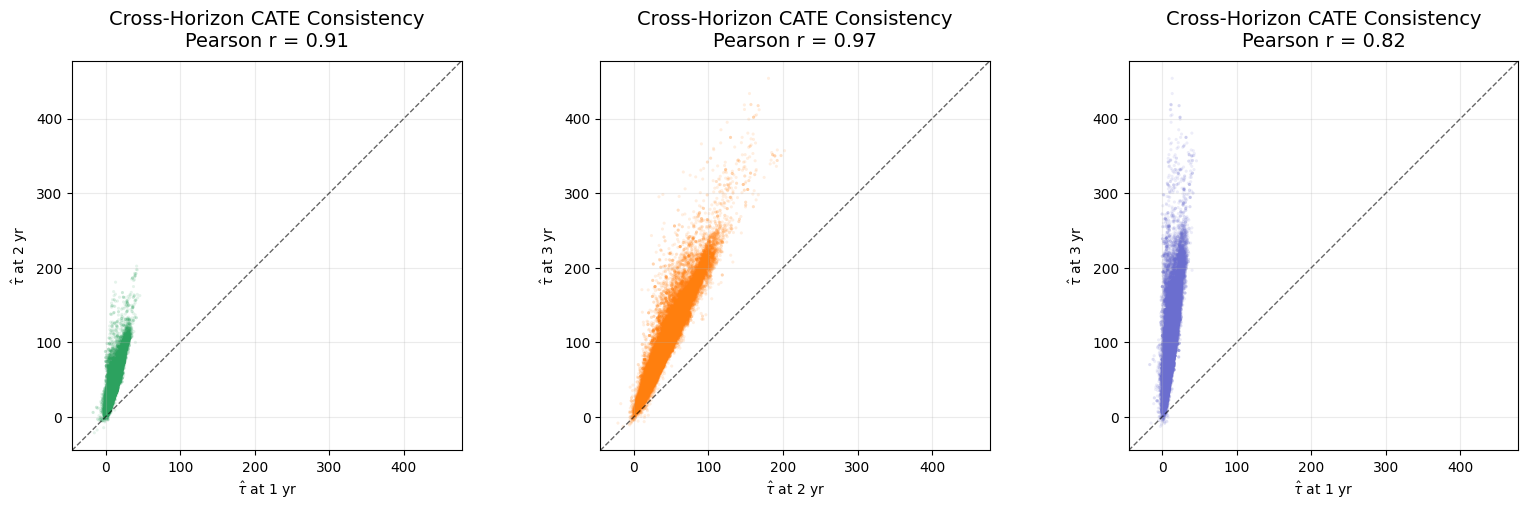

Saved:
- /Users/chanyoungwoo/Thesis/ATE_CATE/fig_cate_cross_horizon_correlations.png
- /Users/chanyoungwoo/Thesis/ATE_CATE/fig_cate_cross_horizon_correlations.pdf


In [17]:
r12, _ = pearsonr(df_test["tau1"], df_test["tau2"])
r23, _ = pearsonr(df_test["tau2"], df_test["tau3"])
r13, _ = pearsonr(df_test["tau1"], df_test["tau3"])

plt.figure(figsize=(16, 5))
pairs = [
    ("tau1", "tau2", f"Cross-Horizon CATE Consistency\nPearson r = {r12:.2f}", "#2ca25f"),
    ("tau2", "tau3", f"Cross-Horizon CATE Consistency\nPearson r = {r23:.2f}", "#ff7f0e"),
    ("tau1", "tau3", f"Cross-Horizon CATE Consistency\nPearson r = {r13:.2f}", "#6b6ecf"),
]

for i, (xcol, ycol, title, color) in enumerate(pairs, start=1):
    ax = plt.subplot(1, 3, i)
    ax.scatter(df_test[xcol], df_test[ycol], s=5, alpha=0.12, color=color, edgecolor="none")
    ax.plot([xmin, xmax], [ymin, ymax], ls="--", lw=1, color="k", alpha=0.6)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"$\\hat\\tau$ at { {'tau1':'1 yr','tau2':'2 yr','tau3':'3 yr'}[xcol] }")
    ax.set_ylabel(f"$\\hat\\tau$ at { {'tau1':'1 yr','tau2':'2 yr','tau3':'3 yr'}[ycol] }")
    ax.set_title(title, fontsize=14, pad=10)
    ax.grid(True, alpha=0.25)

plt.tight_layout()

out_png = MAIN_DIR / "fig_cate_cross_horizon_correlations.png"
out_pdf = MAIN_DIR / "fig_cate_cross_horizon_correlations.pdf"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
plt.show()

print(f"Saved:\n- {out_png}\n- {out_pdf}")
